# 01 — Exploratory Data Analysis

**Rubric target:** Data Acquisition & Analysis

This notebook profiles all three data sources (transactions, articles, customers),
produces report-ready visualizations, and documents biases/limitations.

Everything here feeds directly into the final report.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/MLII_Final'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# --- Plot style --------------------------------------------------------
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#2D2D2D', '#A8C8E8', '#C4D9A0', '#D4B8E0', '#F2C4C4', '#FFD9A0', '#E8D5B7']

DATA_DIR = Path(f'{PROJECT}/data/parquet')
SPLIT_DIR = Path(f'{PROJECT}/data/split')
FIG_DIR = Path(f'{PROJECT}/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
transactions = pd.read_parquet(DATA_DIR / 'transactions.parquet')
articles     = pd.read_parquet(DATA_DIR / 'articles.parquet')
customers    = pd.read_parquet(DATA_DIR / 'customers.parquet')

print(f'Transactions: {len(transactions):,}  |  Articles: {len(articles):,}  |  Customers: {len(customers):,}')

Transactions: 31,788,324  |  Articles: 105,542  |  Customers: 1,371,980


---
## 1. Transaction Profiling

### 1.1 Dataset overview

In [4]:
print(f"Date range: {transactions['t_dat'].min().date()} → {transactions['t_dat'].max().date()}")
print(f"Unique customers: {transactions['customer_id'].nunique():,}")
print(f"Unique articles:  {transactions['article_id'].nunique():,}")
print(f"\nColumns: {list(transactions.columns)}")
print(f"\nNull counts:")
print(transactions.isnull().sum())
transactions.head()

Date range: 2018-09-20 → 2020-09-22
Unique customers: 1,362,281
Unique articles:  104,547

Columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']

Null counts:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2


### 1.2 📊 Purchase volume over time

Weekly aggregation to spot seasonality and trends.

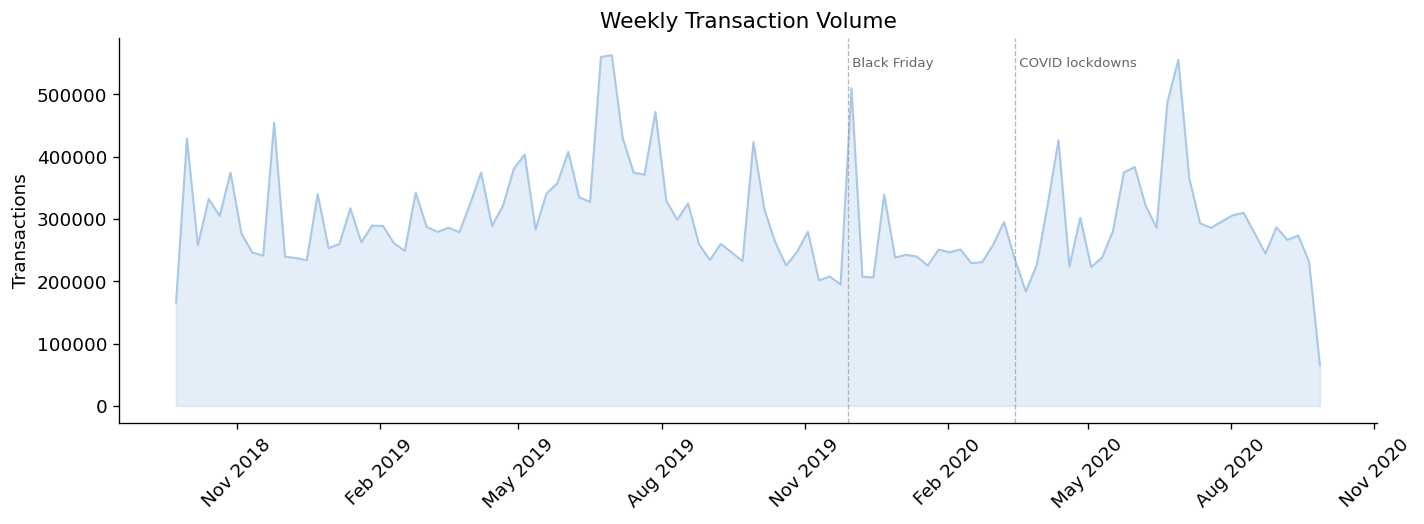

Peak week: 2019-06-30 (562,990 transactions)
Lowest week: 2020-09-27 (64,996 transactions)


In [5]:
weekly = (
    transactions
    .set_index('t_dat')
    .resample('W')['article_id']
    .count()
    .rename('transactions')
    .to_frame()
)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(weekly.index, weekly['transactions'], alpha=0.3, color=PALETTE[1])
ax.plot(weekly.index, weekly['transactions'], color=PALETTE[1], linewidth=1.2)

# Annotate key periods
ax.axvline(pd.Timestamp('2019-11-29'), color='#999', ls='--', lw=0.8, alpha=0.7)
ax.text(pd.Timestamp('2019-11-29'), ax.get_ylim()[1]*0.92, ' Black Friday', fontsize=8, color='#666')
ax.axvline(pd.Timestamp('2020-03-15'), color='#999', ls='--', lw=0.8, alpha=0.7)
ax.text(pd.Timestamp('2020-03-15'), ax.get_ylim()[1]*0.92, ' COVID lockdowns', fontsize=8, color='#666')

ax.set_title('Weekly Transaction Volume')
ax.set_ylabel('Transactions')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIG_DIR / 'weekly_transaction_volume.png', bbox_inches='tight')
plt.show()

print(f"Peak week: {weekly['transactions'].idxmax().date()} ({weekly['transactions'].max():,} transactions)")
print(f"Lowest week: {weekly['transactions'].idxmin().date()} ({weekly['transactions'].min():,} transactions)")

### 1.3 Day-of-week patterns

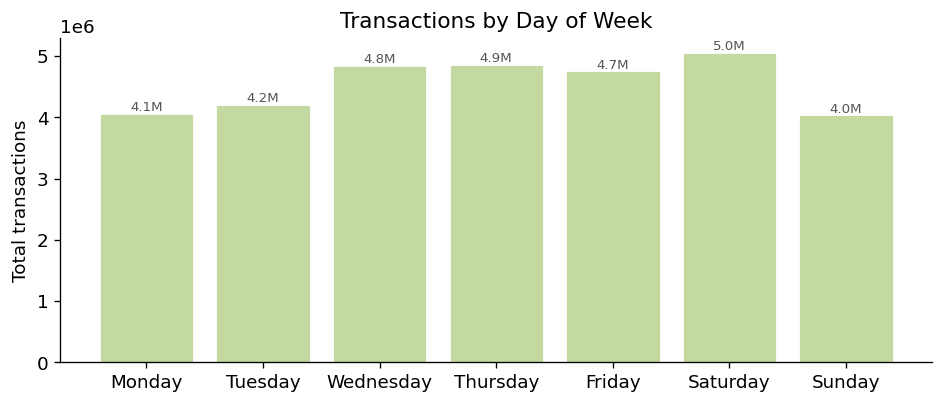

In [6]:
dow = transactions['t_dat'].dt.day_name().value_counts()
dow = dow.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(dow.index, dow.values, color=PALETTE[2], edgecolor='white', linewidth=0.5)
ax.set_title('Transactions by Day of Week')
ax.set_ylabel('Total transactions')
for i, v in enumerate(dow.values):
    ax.text(i, v + dow.max()*0.01, f'{v/1e6:.1f}M', ha='center', fontsize=8, color='#555')
plt.tight_layout()
fig.savefig(FIG_DIR / 'day_of_week.png', bbox_inches='tight')
plt.show()

### 1.4 📊 Purchases per customer (activity distribution)

In [7]:
purchases_per_cust = transactions.groupby('customer_id').size()

print(f"Purchases per customer:")
print(f"  Mean:   {purchases_per_cust.mean():.1f}")
print(f"  Median: {purchases_per_cust.median():.0f}")
print(f"  Std:    {purchases_per_cust.std():.1f}")
print(f"  Max:    {purchases_per_cust.max()}")
print(f"\nPercentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p}th: {purchases_per_cust.quantile(p/100):.0f}")

Purchases per customer:
  Mean:   23.3
  Median: 9
  Std:    39.2
  Max:    1895

Percentiles:
  25th: 3
  50th: 9
  75th: 27
  90th: 60
  95th: 91
  99th: 187


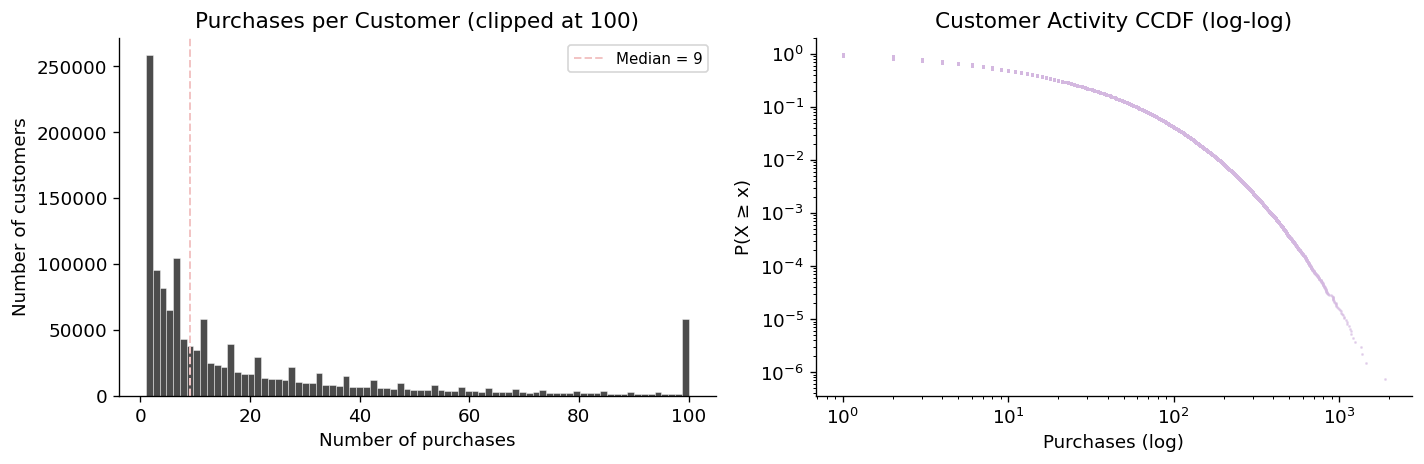

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram clipped at 100
axes[0].hist(purchases_per_cust.clip(upper=100), bins=80, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].set_title('Purchases per Customer (clipped at 100)')
axes[0].set_xlabel('Number of purchases')
axes[0].set_ylabel('Number of customers')
axes[0].axvline(purchases_per_cust.median(), color=PALETTE[4], ls='--', lw=1.2, label=f'Median = {purchases_per_cust.median():.0f}')
axes[0].legend(fontsize=9)

# Right: log-log CCDF
sorted_counts = np.sort(purchases_per_cust.values)[::-1]
ccdf_y = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].loglog(sorted_counts, ccdf_y, '.', markersize=1.5, color=PALETTE[3], alpha=0.5)
axes[1].set_title('Customer Activity CCDF (log-log)')
axes[1].set_xlabel('Purchases (log)')
axes[1].set_ylabel('P(X ≥ x)')

plt.tight_layout()
fig.savefig(FIG_DIR / 'customer_activity_distribution.png', bbox_inches='tight')
plt.show()

### 1.5 Items per transaction

Basket size (items per customer per day):
  Mean:   3.50
  Median: 2
  Max:    570


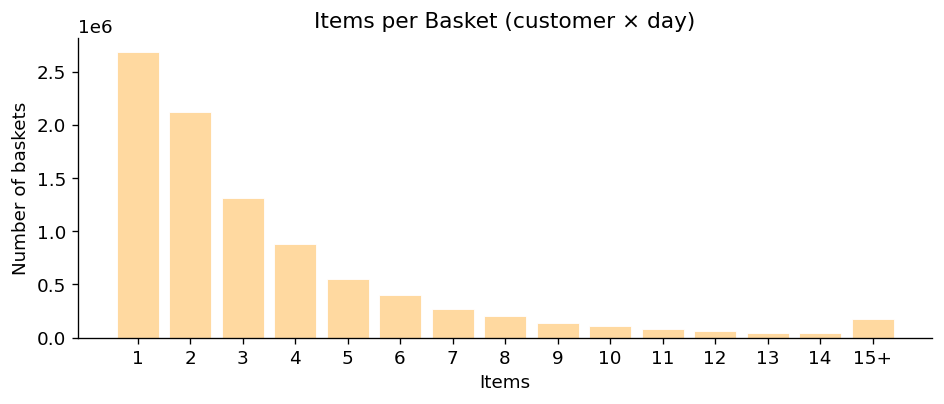

In [9]:
# A "transaction" in this dataset is one row = one item purchase.
# Group by customer + date to approximate basket size.
basket_size = transactions.groupby(['customer_id', 't_dat']).size()

print(f"Basket size (items per customer per day):")
print(f"  Mean:   {basket_size.mean():.2f}")
print(f"  Median: {basket_size.median():.0f}")
print(f"  Max:    {basket_size.max()}")

fig, ax = plt.subplots(figsize=(8, 3.5))
basket_counts = basket_size.clip(upper=15).value_counts().sort_index()
ax.bar(basket_counts.index, basket_counts.values, color=PALETTE[5], edgecolor='white', linewidth=0.5)
ax.set_title('Items per Basket (customer × day)')
ax.set_xlabel('Items')
ax.set_ylabel('Number of baskets')
ax.set_xticks(range(1, 16))
ax.set_xticklabels([str(i) if i < 15 else '15+' for i in range(1, 16)])
plt.tight_layout()
fig.savefig(FIG_DIR / 'basket_size.png', bbox_inches='tight')
plt.show()

### 1.5b Outlier investigation

The max basket size of 570 and max purchases per customer of 1,895 are suspicious.  
Let's check whether these are genuine customers or anomalous accounts.

In [10]:
# Extreme basket sizes
extreme_baskets = basket_size[basket_size >= 50].sort_values(ascending=False)
print(f"Baskets with 50+ items: {len(extreme_baskets):,}")
print(f"Baskets with 100+ items: {(basket_size >= 100).sum():,}")
print(f"Baskets with 200+ items: {(basket_size >= 200).sum():,}")
print(f"\nTop 10 largest baskets:")
print(extreme_baskets.head(10))

# Extreme customers by total purchases
print(f"\n--- Extreme customers (top 20 by total purchases) ---")
top_customers = purchases_per_cust.nlargest(20)
for cid, count in top_customers.items():
    n_days = transactions[transactions['customer_id'] == cid]['t_dat'].nunique()
    avg_per_visit = count / n_days if n_days > 0 else 0
    print(f"  {count:>5} purchases over {n_days:>3} days ({avg_per_visit:.1f} items/visit) — {cid[:12]}...")

print(f"\n→ Customers with extremely high purchase counts may be resellers or store accounts.")
print(f"→ Consider capping at the 99.9th percentile ({purchases_per_cust.quantile(0.999):.0f}) for model training,")
print(f"  or at minimum flagging these for later analysis.")

Baskets with 50+ items: 1,297
Baskets with 100+ items: 88
Baskets with 200+ items: 4

Top 10 largest baskets:
customer_id                                                       t_dat     
d00063b94dcb1342869d4994844a2742b5d62927f36843164fb3f818f630bca9  2018-10-14    570
c2f0cdda2dc3042ccd9fcd8253fd8e368769840581e40aab1d87a64ff39987e3  2018-12-17    336
62fd7d41b587c72a95c31eca5046019ce4e802853397ffd00f354c17007ebd0b  2019-01-13    221
246734d8f4a4252fcd5c7aa525055a2804b9a6fb3d4210e771a33ed98f2bce77  2018-10-15    220
94665b46e194622ccdbcadc0170f13a2f8ede1ff6d057d43a19b8938c808b662  2019-02-16    199
f4e88fe3fae74a3914d566f91d879086a3381946221885af4a7da1221cacbfa3  2019-03-09    184
44322c3d78cb821cd6001e947df46734adb8f9eca560086f86dab0480536e972  2019-11-19    181
631af33bb73cf4d36f5e68b610a3e3006350107b7334be39594181caa9364afa  2018-10-29    180
8465e2822ea250ecdd28081a8a09170f68d047cee45778fb7084b7aa264fe8c9  2020-07-21    178
61da44a2758206d5701771f4315637b40c8321b511191654fb1430a64

### 1.6 Sales channel analysis

The `sales_channel_id` column likely encodes online vs in-store purchases.  
This is an important behavioral signal we shouldn't ignore.

Sales channel breakdown:
  In-store (id=1): 9,408,462 (29.6%)
  Online (id=2): 22,379,862 (70.4%)


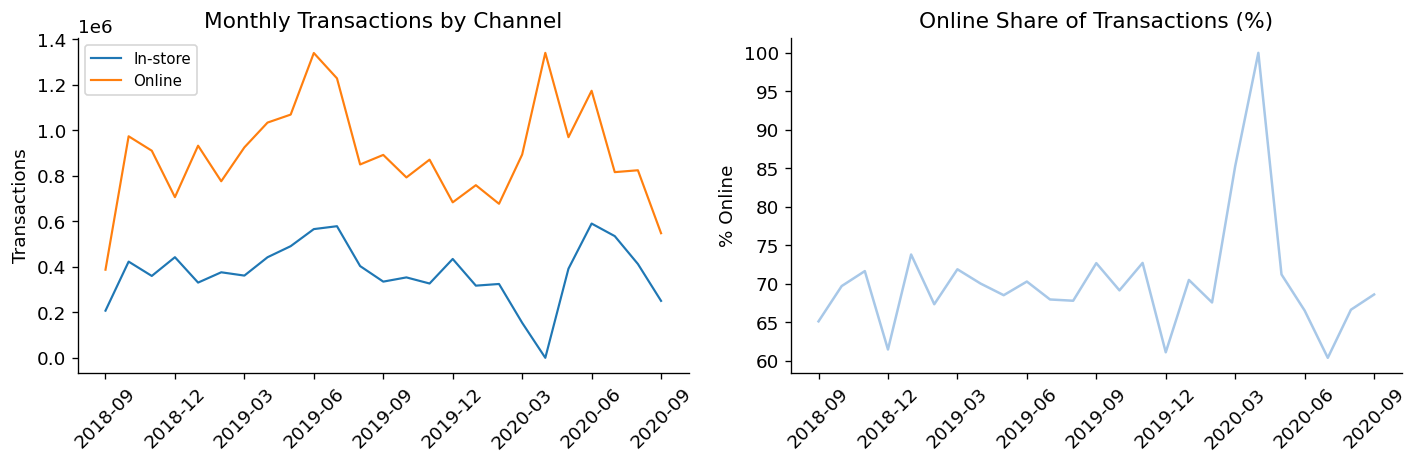

In [11]:
# Sales channel breakdown
channel_counts = transactions['sales_channel_id'].value_counts().sort_index()
channel_labels = {1: 'In-store', 2: 'Online'}

print("Sales channel breakdown:")
for ch, count in channel_counts.items():
    label = channel_labels.get(ch, f'Channel {ch}')
    print(f"  {label} (id={ch}): {count:,} ({count/len(transactions)*100:.1f}%)")

# Channel mix over time (monthly)
txn_channel = transactions.copy()
txn_channel['month'] = txn_channel['t_dat'].dt.to_period('M')
channel_monthly = (
    txn_channel.groupby(['month', 'sales_channel_id'])
    .size()
    .unstack(fill_value=0)
)
channel_monthly_pct = channel_monthly.div(channel_monthly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: absolute volume by channel
for ch in channel_monthly.columns:
    label = channel_labels.get(ch, f'Channel {ch}')
    axes[0].plot(channel_monthly.index.astype(str), channel_monthly[ch],
                 label=label, linewidth=1.3)
axes[0].set_title('Monthly Transactions by Channel')
axes[0].set_ylabel('Transactions')
tick_positions = range(0, len(channel_monthly), 3)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels([channel_monthly.index.astype(str)[i] for i in tick_positions], rotation=45)
axes[0].legend(fontsize=9)

# Right: online share over time
if 2 in channel_monthly_pct.columns:
    axes[1].plot(channel_monthly_pct.index.astype(str), channel_monthly_pct[2],
                 color=PALETTE[1], linewidth=1.5)
    axes[1].set_title('Online Share of Transactions (%)')
    axes[1].set_ylabel('% Online')
    axes[1].set_xticks(tick_positions)
    axes[1].set_xticklabels([channel_monthly_pct.index.astype(str)[i] for i in tick_positions], rotation=45)

plt.tight_layout()
fig.savefig(FIG_DIR / 'sales_channel_analysis.png', bbox_inches='tight')
plt.show()

In [12]:
# Behavioral differences by channel
channel_behavior = transactions.groupby('sales_channel_id').agg(
    n_transactions=('article_id', 'count'),
    n_customers=('customer_id', 'nunique'),
    avg_price=('price', 'mean'),
    n_unique_items=('article_id', 'nunique'),
)
channel_behavior['txn_per_customer'] = channel_behavior['n_transactions'] / channel_behavior['n_customers']
channel_behavior.index = channel_behavior.index.map(lambda x: channel_labels.get(x, f'Channel {x}'))

print("Behavioral differences by channel:")
print(channel_behavior.round(4))

# Do customers use both channels?
channels_per_cust = transactions.groupby('customer_id')['sales_channel_id'].nunique()
both = (channels_per_cust == 2).sum()
print(f"\nCustomers using both channels: {both:,} ({both/len(channels_per_cust)*100:.1f}%)")
print(f"Single-channel customers: {(channels_per_cust == 1).sum():,}")

Behavioral differences by channel:
                  n_transactions  n_customers  avg_price  n_unique_items  \
sales_channel_id                                                           
In-store                 9408462       737118     0.0229           73328   
Online                  22379862      1108418     0.0299           98322   

                  txn_per_customer  
sales_channel_id                    
In-store                   12.7638  
Online                     20.1908  

Customers using both channels: 483,255 (35.5%)
Single-channel customers: 879,026


---
## 2. Article Profiling

### 2.1 Dataset overview

In [13]:
print(f"Articles: {len(articles):,}")
print(f"\nColumns: {list(articles.columns)}")
print(f"\nNull counts:")
print(articles.isnull().sum())
print(f"\nKey categorical cardinalities:")
for col in ['product_type_name', 'product_group_name', 'department_name', 'index_group_name', 'section_name', 'garment_group_name', 'colour_group_name']:
    if col in articles.columns:
        print(f"  {col}: {articles[col].nunique()} unique")
articles.head()

Articles: 105,542

Columns: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']

Null counts:
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_c

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


### 2.1b Product code vs article ID (SKU hierarchy)

Multiple `article_id` values share the same `product_code` — this is the  
color/size variant structure. Understanding this hierarchy matters for modeling.

In [14]:
# How many article_ids per product_code?
variants_per_product = articles.groupby('product_code')['article_id'].nunique()

print(f"Product codes (models): {len(variants_per_product):,}")
print(f"Article IDs (SKUs):     {len(articles):,}")
print(f"Avg variants per product: {variants_per_product.mean():.1f}")
print(f"Max variants per product: {variants_per_product.max()}")

print(f"\nVariants per product distribution:")
for n in [1, 2, 3, 4, 5]:
    count = (variants_per_product == n).sum()
    print(f"  {n} variant(s): {count:,} products ({count/len(variants_per_product)*100:.1f}%)")
print(f"  6+ variants: {(variants_per_product >= 6).sum():,} products")

# Example: show variants of a popular product
popular_product = (
    transactions.merge(articles[['article_id', 'product_code']], on='article_id')
    ['product_code'].value_counts().index[0]
)
print(f"\nExample — most popular product code ({popular_product}):")
example_variants = articles[articles['product_code'] == popular_product][['article_id', 'prod_name', 'colour_group_name']]
print(example_variants.to_string(index=False))
print(f"\n→ product_code = the 'model', article_id = specific color/size SKU")
print(f"→ Consider features at both levels: product-level popularity + SKU-level color preferences")

Product codes (models): 47,224
Article IDs (SKUs):     105,542
Avg variants per product: 2.2
Max variants per product: 75

Variants per product distribution:
  1 variant(s): 24,066 products (51.0%)
  2 variant(s): 11,921 products (25.2%)
  3 variant(s): 4,947 products (10.5%)
  4 variant(s): 2,376 products (5.0%)
  5 variant(s): 1,189 products (2.5%)
  6+ variants: 2,725 products

Example — most popular product code (706016):
article_id                prod_name colour_group_name
0706016001 Jade HW Skinny Denim TRS             Black
0706016002 Jade HW Skinny Denim TRS        Light Blue
0706016003 Jade HW Skinny Denim TRS         Dark Blue
0706016004 Jade HW Skinny Denim TRS        Light Blue
0706016006 Jade HW Skinny Denim TRS         Dark Blue
0706016007 Jade HW Skinny Denim TRS         Dark Blue
0706016008        Jade Denim HW trs        Light Grey
0706016009        Jade Denim HW trs             Beige
0706016010        Jade HW denim trs             White
0706016011        Jade HW deni

### 2.2 📊 Item popularity distribution (power law)

This is one of the most important plots — it shows the popularity bias in the data.

In [15]:
item_counts = transactions['article_id'].value_counts()

# Stats
n_items = len(item_counts)
top_1pct = int(n_items * 0.01)
top_1pct_share = item_counts.head(top_1pct).sum() / item_counts.sum() * 100
top_10pct = int(n_items * 0.10)
top_10pct_share = item_counts.head(top_10pct).sum() / item_counts.sum() * 100

print(f"Total unique items sold: {n_items:,}")
print(f"Top 1% of items ({top_1pct:,} items) account for {top_1pct_share:.1f}% of transactions")
print(f"Top 10% of items ({top_10pct:,} items) account for {top_10pct_share:.1f}% of transactions")
print(f"\nItems sold only once: {(item_counts == 1).sum():,} ({(item_counts == 1).sum()/n_items*100:.1f}%)")
print(f"Items in catalog but never sold: {len(articles) - n_items:,}")

Total unique items sold: 104,547
Top 1% of items (1,045 items) account for 18.6% of transactions
Top 10% of items (10,454 items) account for 60.7% of transactions

Items sold only once: 4,491 (4.3%)
Items in catalog but never sold: 995


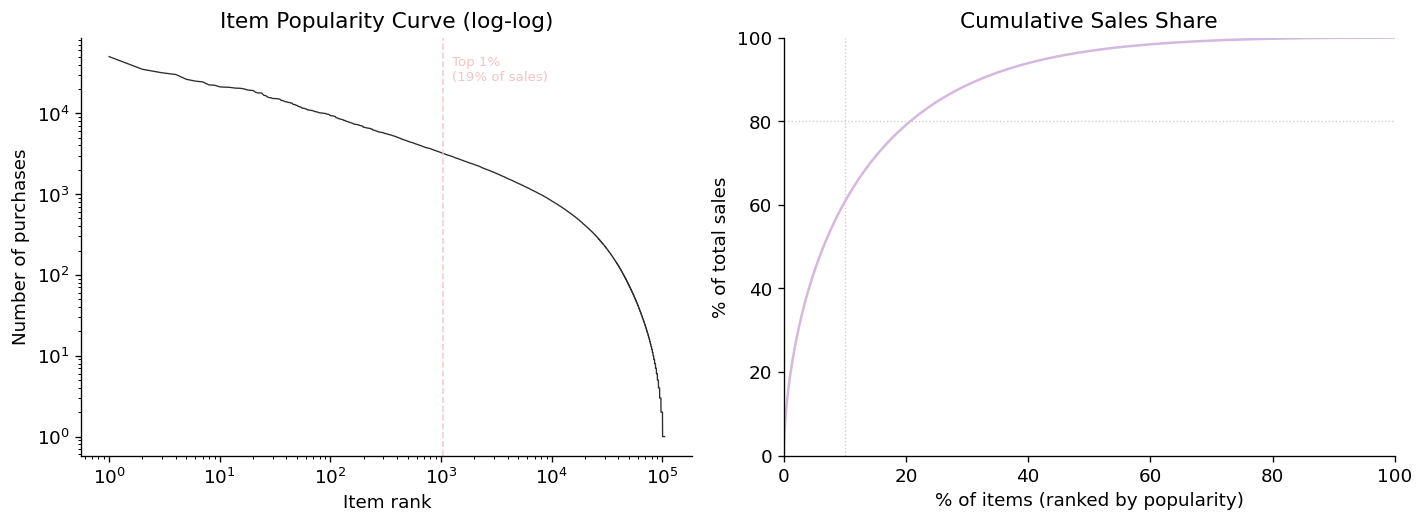

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: rank vs count (log-log)
ranks = np.arange(1, len(item_counts)+1)
axes[0].loglog(ranks, item_counts.values, color=PALETTE[0], linewidth=0.8)
axes[0].axvline(top_1pct, color=PALETTE[4], ls='--', lw=1, alpha=0.8)
axes[0].text(top_1pct*1.2, item_counts.values[0]*0.5, f'Top 1%\n({top_1pct_share:.0f}% of sales)', fontsize=8, color=PALETTE[4])
axes[0].set_title('Item Popularity Curve (log-log)')
axes[0].set_xlabel('Item rank')
axes[0].set_ylabel('Number of purchases')

# Right: cumulative share
cumulative_share = np.cumsum(item_counts.values) / item_counts.sum()
pct_items = ranks / len(item_counts) * 100
axes[1].plot(pct_items, cumulative_share * 100, color=PALETTE[3], linewidth=1.5)
axes[1].axhline(80, color='#CCC', ls=':', lw=0.8)
axes[1].axvline(10, color='#CCC', ls=':', lw=0.8)
axes[1].set_title('Cumulative Sales Share')
axes[1].set_xlabel('% of items (ranked by popularity)')
axes[1].set_ylabel('% of total sales')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
fig.savefig(FIG_DIR / 'item_popularity_distribution.png', bbox_inches='tight')
plt.show()

### 2.3 📊 Top product categories

In [17]:
# Merge article metadata onto transactions to get category-level sales
txn_with_meta = transactions.merge(articles[['article_id', 'product_group_name', 'department_name', 'index_group_name']], on='article_id', how='left')

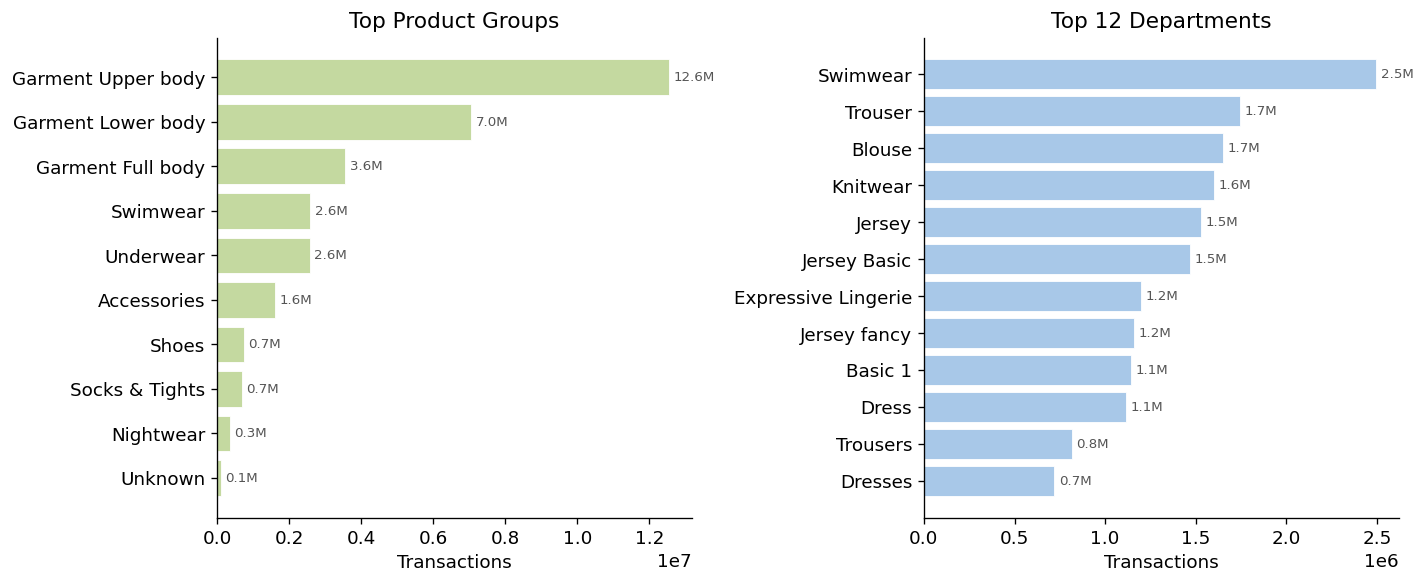

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Product group
pg = txn_with_meta['product_group_name'].value_counts().head(10)
axes[0].barh(pg.index[::-1], pg.values[::-1], color=PALETTE[2], edgecolor='white', linewidth=0.5)
axes[0].set_title('Top Product Groups')
axes[0].set_xlabel('Transactions')
for i, v in enumerate(pg.values[::-1]):
    axes[0].text(v + pg.max()*0.01, i, f'{v/1e6:.1f}M', va='center', fontsize=8, color='#555')

# Department
dept = txn_with_meta['department_name'].value_counts().head(12)
axes[1].barh(dept.index[::-1], dept.values[::-1], color=PALETTE[1], edgecolor='white', linewidth=0.5)
axes[1].set_title('Top 12 Departments')
axes[1].set_xlabel('Transactions')
for i, v in enumerate(dept.values[::-1]):
    axes[1].text(v + dept.max()*0.01, i, f'{v/1e6:.1f}M', va='center', fontsize=8, color='#555')

plt.tight_layout()
fig.savefig(FIG_DIR / 'category_breakdown.png', bbox_inches='tight')
plt.show()

### 2.4 Text descriptions (`detail_desc`)

The articles table includes free-text product descriptions.  
These could be useful for content-based features (TF-IDF, embeddings).

In [19]:
# detail_desc exploration
print(f"detail_desc coverage: {articles['detail_desc'].notna().sum():,} / {len(articles):,} "
      f"({articles['detail_desc'].notna().mean()*100:.1f}%)")
print(f"Missing: {articles['detail_desc'].isna().sum()} articles\n")

# Sample descriptions
print("Sample descriptions:")
for _, row in articles[articles['detail_desc'].notna()].sample(5, random_state=42).iterrows():
    print(f"  [{row['product_type_name']}] {row['detail_desc'][:120]}")

# Description length distribution
desc_lengths = articles['detail_desc'].dropna().str.len()
print(f"\nDescription length (characters):")
print(f"  Mean:   {desc_lengths.mean():.0f}")
print(f"  Median: {desc_lengths.median():.0f}")
print(f"  Min:    {desc_lengths.min():.0f}")
print(f"  Max:    {desc_lengths.max():.0f}")

print(f"\n→ Text descriptions available for nearly all articles.")
print(f"→ Could be used for TF-IDF features or sentence embeddings in the ranker.")
print(f"→ Listed as a Potential Improvement if not used in main pipeline.")

detail_desc coverage: 105,126 / 105,542 (99.6%)
Missing: 416 articles

Sample descriptions:
  [Sweater] Top in lightweight sweatshirt fabric with dropped shoulders, and ribbing around the neckline, cuffs and hem.
  [Trousers] Suit trousers in a stretch weave with a regular waist, concealed hook-and-eye fastening and zip fly. Side pockets and ta
  [Jumpsuit/Playsuit] Sleeveless playsuit in soft, patterned cotton jersey with a raw-edge, flounced trim at the top and small opening with a 
  [Dress] Short dress in soft jersey with a V-neck, narrow, adjustable shoulder straps, seam at the waist and flared skirt.
  [Bracelet] Bracelets in various designs. Two are made of waxed cotton cord, one decorated with metal beads. The other two are made 

Description length (characters):
  Mean:   142
  Median: 132
  Min:    11
  Max:    764

→ Text descriptions available for nearly all articles.
→ Could be used for TF-IDF features or sentence embeddings in the ranker.
→ Listed as a Potential Improveme

### 2.5 Price distribution

Price stats (appears to be normalized/scaled):
count    3.178832e+07
mean     2.782927e-02
std      1.918113e-02
min      1.694915e-05
25%      1.581356e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.915254e-01
Name: price, dtype: float64


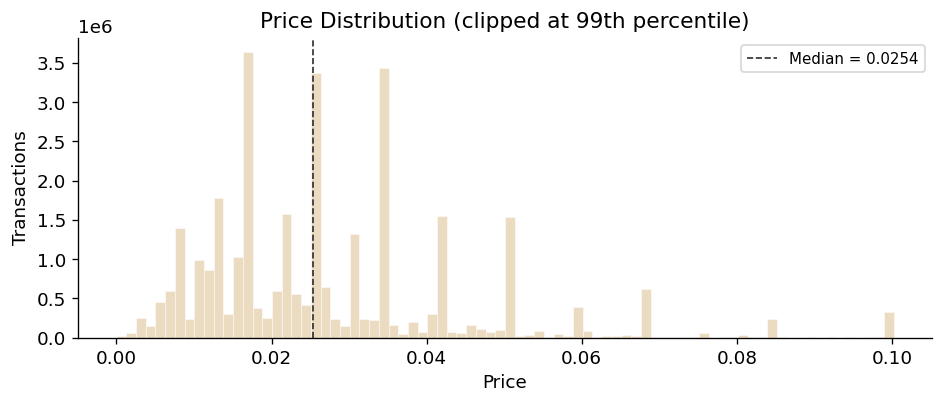

In [20]:
print(f"Price stats (appears to be normalized/scaled):")
print(transactions['price'].describe())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(transactions['price'].clip(upper=transactions['price'].quantile(0.99)), bins=80, color=PALETTE[6], edgecolor='white', linewidth=0.3, alpha=0.85)
ax.set_title('Price Distribution (clipped at 99th percentile)')
ax.set_xlabel('Price')
ax.set_ylabel('Transactions')
ax.axvline(transactions['price'].median(), color=PALETTE[0], ls='--', lw=1, label=f"Median = {transactions['price'].median():.4f}")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'price_distribution.png', bbox_inches='tight')
plt.show()

In [21]:
# Price data quality checks
print("Price data quality:")
print(f"  Zero prices: {(transactions['price'] == 0).sum():,}")
print(f"  Negative prices: {(transactions['price'] < 0).sum():,}")
print(f"  Min price: {transactions['price'].min():.6f}")
print(f"  Max price: {transactions['price'].max():.6f}")

# H&M is Swedish — prices likely in SEK. Typical t-shirt ~100-200 SEK.
print(f"\nPrice interpretation (if scale factor ≈ 1/1000):")
print(f"  Median price: ~{transactions['price'].median() * 1000:.0f} SEK")
print(f"  Mean price:   ~{transactions['price'].mean() * 1000:.0f} SEK")
print(f"  Note: prices appear normalized. Exact scale unknown,")
print(f"  but relative differences are what matter for features.")

# Check for suspicious spikes at round numbers
print(f"\nMost common prices (top 10):")
price_freq = transactions['price'].round(6).value_counts().head(10)
for price, count in price_freq.items():
    print(f"  {price:.6f}: {count:,} transactions")

Price data quality:
  Zero prices: 0
  Negative prices: 0
  Min price: 0.000017
  Max price: 0.591525

Price interpretation (if scale factor ≈ 1/1000):
  Median price: ~25 SEK
  Mean price:   ~28 SEK
  Note: prices appear normalized. Exact scale unknown,
  but relative differences are what matter for features.

Most common prices (top 10):
  0.016932: 3,416,921 transactions
  0.033881: 3,406,538 transactions
  0.025407: 3,266,926 transactions
  0.013542: 1,497,769 transactions
  0.050831: 1,494,130 transactions
  0.042356: 1,485,660 transactions
  0.022017: 1,287,249 transactions
  0.030492: 1,221,011 transactions
  0.008458: 1,074,468 transactions
  0.015237: 705,244 transactions


---
## 3. Customer Profiling

### 3.1 Dataset overview

In [22]:
print(f"Customers: {len(customers):,}")
print(f"\nColumns: {list(customers.columns)}")
print(f"\nNull counts:")
print(customers.isnull().sum())
print(f"\nNull percentages:")
print((customers.isnull().sum() / len(customers) * 100).round(1))
customers.head()

Customers: 1,371,980

Columns: ['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']

Null counts:
customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

Null percentages:
customer_id                0.0
FN                        65.2
Active                    66.2
club_member_status         0.4
fashion_news_frequency     1.2
age                        1.2
postal_code                0.0
dtype: float64


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


### 3.2 Age distribution

Age stats:
count    1.356119e+06
mean     3.638696e+01
std      1.431363e+01
min      1.600000e+01
25%      2.400000e+01
50%      3.200000e+01
75%      4.900000e+01
max      9.900000e+01
Name: age, dtype: float64

Missing age: 15,861 (1.2%)


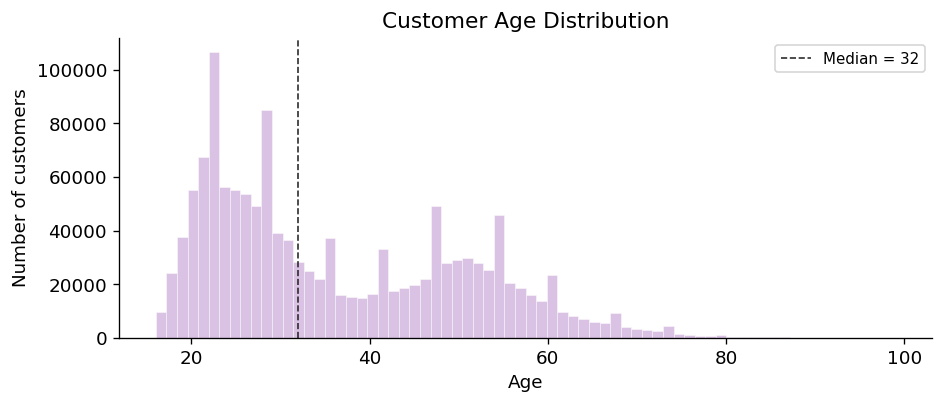

In [23]:
print(f"Age stats:")
print(customers['age'].describe())
print(f"\nMissing age: {customers['age'].isnull().sum():,} ({customers['age'].isnull().mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(customers['age'].dropna(), bins=70, color=PALETTE[3], edgecolor='white', linewidth=0.3, alpha=0.85)
ax.set_title('Customer Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Number of customers')
ax.axvline(customers['age'].median(), color=PALETTE[0], ls='--', lw=1, label=f"Median = {customers['age'].median():.0f}")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'age_distribution.png', bbox_inches='tight')
plt.show()

In [24]:
# Age data quality — check for implausible values
age = customers['age'].dropna()
print("Age data quality:")
print(f"  Min: {age.min():.0f}")
print(f"  Max: {age.max():.0f}")
print(f"  Ages < 15: {(age < 15).sum():,}")
print(f"  Ages > 80: {(age > 80).sum():,}")
print(f"  Ages > 90: {(age > 90).sum():,}")
print(f"  Ages > 100: {(age > 100).sum():,}")

if age.max() > 100 or age.min() < 10:
    print(f"\n⚠ Implausible ages detected.")
    print(f"  Consider clipping to [15, 90] or treating extremes as missing.")
else:
    print(f"\n✓ Age range looks plausible.")

Age data quality:
  Min: 16
  Max: 99
  Ages < 15: 0
  Ages > 80: 1,112
  Ages > 90: 77
  Ages > 100: 0

✓ Age range looks plausible.


### 3.3 Club member status & fashion news subscription

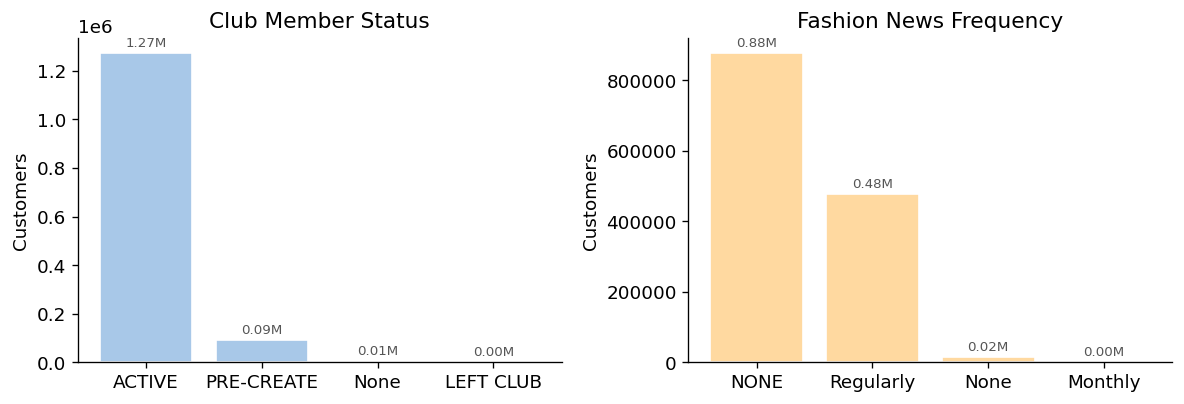

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Club member status
club = customers['club_member_status'].value_counts(dropna=False)
axes[0].bar(club.index.astype(str), club.values, color=PALETTE[1], edgecolor='white')
axes[0].set_title('Club Member Status')
axes[0].set_ylabel('Customers')
for i, v in enumerate(club.values):
    axes[0].text(i, v + club.max()*0.02, f'{v/1e6:.2f}M', ha='center', fontsize=8, color='#555')

# Fashion news
fn = customers['fashion_news_frequency'].value_counts(dropna=False)
axes[1].bar(fn.index.astype(str), fn.values, color=PALETTE[5], edgecolor='white')
axes[1].set_title('Fashion News Frequency')
axes[1].set_ylabel('Customers')
for i, v in enumerate(fn.values):
    axes[1].text(i, v + fn.max()*0.02, f'{v/1e6:.2f}M', ha='center', fontsize=8, color='#555')

plt.tight_layout()
fig.savefig(FIG_DIR / 'customer_segments.png', bbox_inches='tight')
plt.show()

### 3.3b FN and Active columns investigation

The `FN` and `Active` columns are ~65% null. Let's understand what they encode  
and whether their missingness is informative.

In [26]:
# FN and Active cross-tabulation
print("FN × Active cross-tab:")
fn_active = pd.crosstab(customers['FN'].fillna('NaN'), customers['Active'].fillna('NaN'), margins=True)
print(fn_active)

# Are they always NaN together?
both_nan = (customers['FN'].isna() & customers['Active'].isna()).sum()
either_nan = (customers['FN'].isna() | customers['Active'].isna()).sum()
print(f"\nBoth NaN together: {both_nan:,}")
print(f"Either NaN: {either_nan:,}")
print(f"→ {'They are almost always NaN together — same underlying flag.' if both_nan/either_nan > 0.95 else 'They have independent missingness.'}")

# Do customers with FN/Active data behave differently?
cust_with_fn = set(customers[customers['FN'].notna()]['customer_id'])
txn_fn = transactions['customer_id'].isin(cust_with_fn)

print(f"\nBehavior comparison:")
print(f"  With FN data:    {txn_fn.sum():,} txns ({txn_fn.sum()/len(transactions)*100:.1f}%)")
print(f"  Without FN data: {(~txn_fn).sum():,} txns ({(~txn_fn).sum()/len(transactions)*100:.1f}%)")
print(f"\n→ FN/Active likely indicate opt-in to a marketing program.")
print(f"→ Decision: treat NaN as 'not opted in' rather than truly missing.")

FN × Active cross-tab:
Active     1.0     NaN      All
FN                             
1.0     464404   12526   476930
NaN          0  895050   895050
All     464404  907576  1371980

Both NaN together: 895,050
Either NaN: 907,576
→ They are almost always NaN together — same underlying flag.

Behavior comparison:
  With FN data:    13,578,487 txns (42.7%)
  Without FN data: 18,209,837 txns (57.3%)

→ FN/Active likely indicate opt-in to a marketing program.
→ Decision: treat NaN as 'not opted in' rather than truly missing.


### 3.4 Active vs inactive customers

In [27]:
# How many customers in the customer table actually have transactions?
active_customers = transactions['customer_id'].nunique()
total_customers = len(customers)

print(f"Total customers in metadata: {total_customers:,}")
print(f"Customers with ≥1 transaction: {active_customers:,} ({active_customers/total_customers*100:.1f}%)")
print(f"Customers with 0 transactions: {total_customers - active_customers:,} ({(total_customers - active_customers)/total_customers*100:.1f}%)")

# Recency: when was each customer's last purchase?
last_purchase = transactions.groupby('customer_id')['t_dat'].max()
max_date = transactions['t_dat'].max()
days_since_last = (max_date - last_purchase).dt.days

print(f"\nDays since last purchase:")
print(f"  Median: {days_since_last.median():.0f} days")
print(f"  Mean:   {days_since_last.mean():.0f} days")
print(f"  Active in last 30 days:  {(days_since_last <= 30).sum():,}")
print(f"  Active in last 90 days:  {(days_since_last <= 90).sum():,}")
print(f"  Inactive >365 days:      {(days_since_last > 365).sum():,}")

Total customers in metadata: 1,371,980
Customers with ≥1 transaction: 1,362,281 (99.3%)
Customers with 0 transactions: 9,699 (0.7%)

Days since last purchase:
  Median: 151 days
  Mean:   235 days
  Active in last 30 days:  250,619
  Active in last 90 days:  525,075
  Inactive >365 days:      367,961


### 3.5 Purchase behavior by age group

In [28]:
# Merge age onto transactions
txn_age = transactions.merge(customers[['customer_id', 'age']], on='customer_id', how='left')

# Create age buckets
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
txn_age['age_group'] = pd.cut(txn_age['age'], bins=bins, labels=labels, right=False)

age_stats = txn_age.groupby('age_group', observed=False).agg(
    transactions=('article_id', 'count'),
    avg_price=('price', 'mean'),
    unique_items=('article_id', 'nunique'),
    n_customers=('customer_id', 'nunique'),
).round(4)

# Add per-customer normalization
age_stats['txn_per_customer'] = (age_stats['transactions'] / age_stats['n_customers']).round(1)
age_stats['items_per_customer'] = (age_stats['unique_items'] / age_stats['n_customers']).round(1)

print("Purchase behavior by age group (with per-customer normalization):")
age_stats

Purchase behavior by age group (with per-customer normalization):


,transactions,avg_price,unique_items,n_customers,txn_per_customer,items_per_customer
age_group,,,,,,
<20,691402,0.0236,46336,70512,9.8,0.7
20-29,13058587,0.0271,92894,524688,24.9,0.2
30-39,6428863,0.0280,96605,232664,27.6,0.4
40-49,4908363,0.0276,92424,202797,24.2,0.5
50-59,5136958,0.0294,86279,224865,22.8,0.4
60+,1423893,0.0305,72233,90994,15.6,0.8


---
## 4. Temporal Patterns & Seasonality

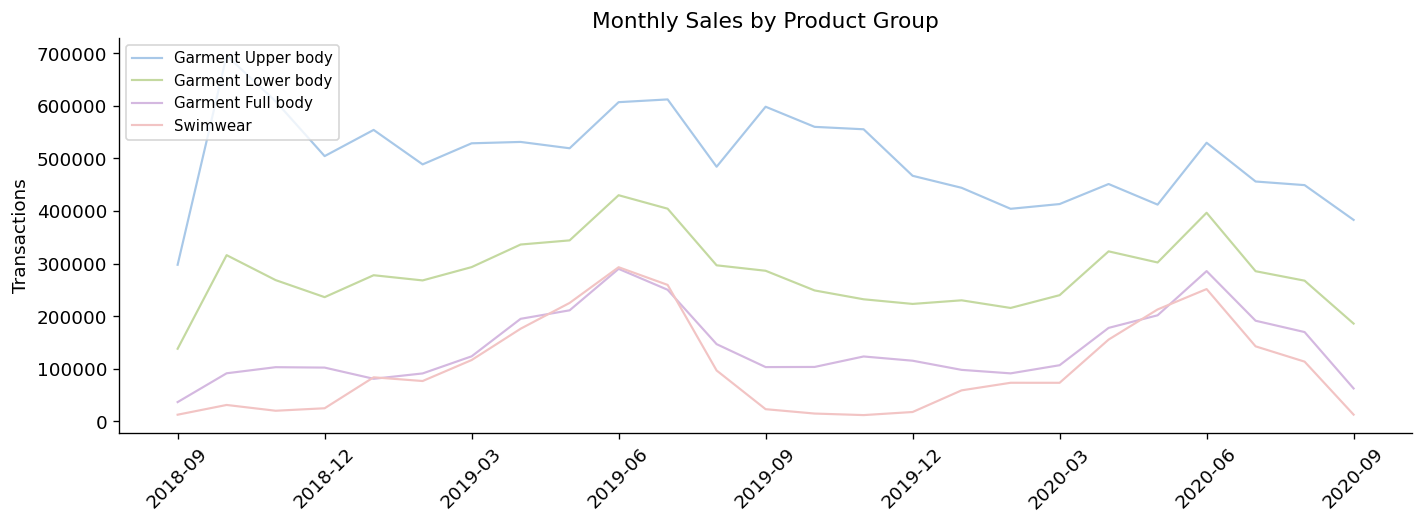

In [29]:
# Monthly sales by top product groups
txn_with_meta['month'] = txn_with_meta['t_dat'].dt.to_period('M')
top_groups = txn_with_meta['product_group_name'].value_counts().head(4).index

monthly_by_group = (
    txn_with_meta[txn_with_meta['product_group_name'].isin(top_groups)]
    .groupby(['month', 'product_group_name'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
for i, group in enumerate(top_groups):
    ax.plot(monthly_by_group.index.astype(str), monthly_by_group[group],
            label=group, color=PALETTE[i+1], linewidth=1.3)

ax.set_title('Monthly Sales by Product Group')
ax.set_ylabel('Transactions')
# Show every 3rd month label to avoid crowding
tick_positions = range(0, len(monthly_by_group), 3)
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly_by_group.index.astype(str)[i] for i in tick_positions], rotation=45)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
fig.savefig(FIG_DIR / 'monthly_sales_by_group.png', bbox_inches='tight')
plt.show()

### 4.1 Repeat purchase rate

In [30]:
# How often do customers re-purchase the same article?
repeat_purchases = transactions.groupby(['customer_id', 'article_id']).size()
total_pairs = len(repeat_purchases)
repeat_pairs = (repeat_purchases > 1).sum()

print(f"Unique (customer, article) pairs: {total_pairs:,}")
print(f"Pairs with repeat purchase:       {repeat_pairs:,} ({repeat_pairs/total_pairs*100:.1f}%)")
print(f"\nThis tells us how viable a 'repurchase' baseline is.")

# Distribution of repeat counts
repeat_dist = repeat_purchases.value_counts().sort_index().head(10)
print(f"\nRepurchase count distribution:")
for count, freq in repeat_dist.items():
    print(f"  Bought {count}x: {freq:,} pairs")

Unique (customer, article) pairs: 27,306,439
Pairs with repeat purchase:       3,515,413 (12.9%)

This tells us how viable a 'repurchase' baseline is.

Repurchase count distribution:
  Bought 1x: 23,791,026 pairs
  Bought 2x: 2,937,962 pairs
  Bought 3x: 389,905 pairs
  Bought 4x: 119,749 pairs
  Bought 5x: 28,747 pairs
  Bought 6x: 18,424 pairs
  Bought 7x: 5,854 pairs
  Bought 8x: 4,632 pairs
  Bought 9x: 2,359 pairs
  Bought 10x: 2,097 pairs


---
## 5. Summary Statistics Table

Quick reference for the report.

In [31]:
summary = {
    'Total transactions': f"{len(transactions):,}",
    'Date range': f"{transactions['t_dat'].min().date()} → {transactions['t_dat'].max().date()}",
    'Unique customers (with transactions)': f"{transactions['customer_id'].nunique():,}",
    'Unique articles (sold)': f"{transactions['article_id'].nunique():,}",
    'Total articles in catalog': f"{len(articles):,}",
    'Unique product codes (models)': f"{articles['product_code'].nunique():,}",
    'Total customers in metadata': f"{len(customers):,}",
    'Median purchases per customer': f"{purchases_per_cust.median():.0f}",
    'Median basket size': f"{basket_size.median():.0f}",
    'Repeat purchase rate': f"{repeat_pairs/total_pairs*100:.1f}%",
    'Top 1% items share of sales': f"{top_1pct_share:.1f}%",
    'Missing age rate': f"{customers['age'].isnull().mean()*100:.1f}%",
    'FN/Active null rate': f"{customers['FN'].isnull().mean()*100:.1f}%",
    'Sales channels': f"{transactions['sales_channel_id'].nunique()}",
    'Articles with text descriptions': f"{articles['detail_desc'].notna().sum():,} ({articles['detail_desc'].notna().mean()*100:.1f}%)",
}

for k, v in summary.items():
    print(f"{k:42s} {v}")

Total transactions                         31,788,324
Date range                                 2018-09-20 → 2020-09-22
Unique customers (with transactions)       1,362,281
Unique articles (sold)                     104,547
Total articles in catalog                  105,542
Unique product codes (models)              47,224
Total customers in metadata                1,371,980
Median purchases per customer              9
Median basket size                         2
Repeat purchase rate                       12.9%
Top 1% items share of sales                18.6%
Missing age rate                           1.2%
FN/Active null rate                        65.2%
Sales channels                             2
Articles with text descriptions            105,126 (99.6%)


---
## Figures saved

All plots have been saved to `outputs/figures/` for use in the final report.

In [32]:
import os
print("Saved figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")

Saved figures:
  age_distribution.png
  basket_size.png
  category_breakdown.png
  customer_activity_distribution.png
  customer_segments.png
  day_of_week.png
  item_popularity_distribution.png
  monthly_sales_by_group.png
  price_distribution.png
  sales_channel_analysis.png
  seasonal_pattern.png
  weekly_transaction_volume.png
